# UAS - Klasifikasi Otomasi Industri (SECOM Semiconductor Manufacturing Dataset)

**Domain:** Otomasi / Manufaktur (Semiconductor Manufacturing Process)

**Dataset:** SECOM - UCI Machine Learning Repository
(sumber: https://archive.ics.uci.edu/dataset/179/secom)

**Deskripsi singkat dataset:**
Dataset ini berisi 1567 data hasil monitoring sensor pada proses manufaktur semikonduktor (590 fitur sinyal sensor per baris data), dengan label **pass (-1)** atau **fail (1)** hasil uji kualitas produk. Dataset ini sangat relevan dengan bidang **otomasi industri**, karena merepresentasikan sistem pemantauan otomatis (automated monitoring system) pada lini produksi.

**Metode AI yang digunakan:** K-Nearest Neighbors (KNN)

**Tahapan pada notebook ini:**
1. Unduh & muat dataset
2. Eksplorasi data awal
3. Preprocessing data (missing value, fitur konstan, korelasi tinggi, scaling)
4. Ekstraksi fitur (PCA)
5. Klasifikasi dengan KNN
6. Analisis hasil klasifikasi: Confusion Matrix, ROC, histogram, sebaran data

## 1. Import Library

In [1]:
import os
import io
import zipfile
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, classification_report, accuracy_score
)
from sklearn.utils import resample

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")


## 2. Unduh & Muat Dataset SECOM

Dataset diunduh langsung dari UCI Machine Learning Repository (format `.zip` berisi `secom.data` dan `secom_labels.data`).

In [2]:
DATA_DIR = "secom_data"
os.makedirs(DATA_DIR, exist_ok=True)

ZIP_URL = "https://archive.ics.uci.edu/static/public/179/secom.zip"
zip_path = os.path.join(DATA_DIR, "secom.zip")

if not os.path.exists(os.path.join(DATA_DIR, "secom.data")):
    print("Mengunduh dataset SECOM dari UCI...")
    urllib.request.urlretrieve(ZIP_URL, zip_path)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(DATA_DIR)
    print("Selesai mengunduh & mengekstrak dataset.")
else:
    print("Dataset sudah tersedia secara lokal.")

os.listdir(DATA_DIR)


Mengunduh dataset SECOM dari UCI...
Selesai mengunduh & mengekstrak dataset.


['secom.names', 'secom.data', 'secom.zip', 'secom_labels.data']

In [3]:
# secom.data : 1567 baris x 590 fitur, dipisahkan spasi, nilai kosong = 'NaN'
# secom_labels.data : label (-1 = pass, 1 = fail) + timestamp

X_raw = pd.read_csv(os.path.join(DATA_DIR, "secom.data"), sep=r"\s+", header=None)
labels_raw = pd.read_csv(os.path.join(DATA_DIR, "secom_labels.data"), sep=r"\s+", header=None,
                          names=["label", "timestamp"])

X_raw.columns = [f"sensor_{i+1}" for i in range(X_raw.shape[1])]
y_raw = labels_raw["label"]

df = X_raw.copy()
df["label"] = y_raw.values

print("Ukuran data:", df.shape)
df.head()


Ukuran data: (1567, 591)


,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,...,sensor_582,sensor_583,sensor_584,sensor_585,sensor_586,sensor_587,sensor_588,sensor_589,sensor_590,label
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


## 3. Eksplorasi Data Awal

In [4]:
print("Distribusi kelas (label):")
print(df["label"].value_counts())
print()
print("Persentase missing value per kolom (10 tertinggi):")
print((X_raw.isna().mean() * 100).sort_values(ascending=False).head(10))


Distribusi kelas (label):
label
-1    1463
 1     104
Name: count, dtype: int64

Persentase missing value per kolom (10 tertinggi):
sensor_293    91.193363
sensor_294    91.193363
sensor_159    91.193363
sensor_158    91.193363
sensor_493    85.577537
sensor_86     85.577537
sensor_359    85.577537
sensor_221    85.577537
sensor_245    64.964901
sensor_518    64.964901
dtype: float64


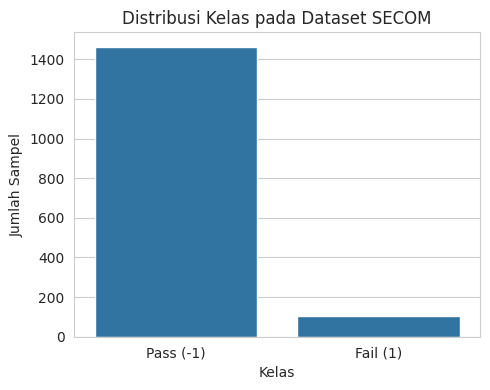

In [5]:
plt.figure(figsize=(5,4))
sns.countplot(x=df["label"].map({-1: "Pass (-1)", 1: "Fail (1)"}))
plt.title("Distribusi Kelas pada Dataset SECOM")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Sampel")
plt.tight_layout()
plt.show()


## 4. Preprocessing Data

Langkah preprocessing yang dilakukan:
1. Membuang kolom dengan proporsi missing value yang sangat tinggi (>55%)
2. Imputasi missing value sisanya dengan **median** tiap kolom
3. Membuang fitur konstan / variansi mendekati nol
4. Membuang fitur yang berkorelasi sangat tinggi (>0.95) untuk mengurangi redundansi
5. Standardisasi (scaling) fitur dengan `StandardScaler`

In [6]:
X = X_raw.copy()

# 1. Buang kolom dengan missing value > 55%
missing_ratio = X.isna().mean()
cols_keep = missing_ratio[missing_ratio < 0.55].index
X = X[cols_keep]
print("Jumlah fitur setelah buang kolom missing tinggi:", X.shape[1])

# 2. Imputasi missing value dengan median
imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# 3. Buang fitur konstan / variansi mendekati nol
variances = X_imputed.var()
X_imputed = X_imputed.loc[:, variances > 1e-6]
print("Jumlah fitur setelah buang fitur konstan:", X_imputed.shape[1])

# 4. Buang fitur berkorelasi tinggi (>0.95)
corr_matrix = X_imputed.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [c for c in upper.columns if any(upper[c] > 0.95)]
X_clean = X_imputed.drop(columns=to_drop)
print("Jumlah fitur setelah buang fitur berkorelasi tinggi:", X_clean.shape[1])

# 5. Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)
print("Bentuk data akhir setelah preprocessing:", X_scaled.shape)


Jumlah fitur setelah buang kolom missing tinggi: 566
Jumlah fitur setelah buang fitur konstan: 440
Jumlah fitur setelah buang fitur berkorelasi tinggi: 270
Bentuk data akhir setelah preprocessing: (1567, 270)


## 5. Ekstraksi Fitur (TP2)

Karena jumlah fitur masih besar (ratusan sinyal sensor), dilakukan **ekstraksi fitur dengan PCA (Principal Component Analysis)** untuk mereduksi dimensi sekaligus mempertahankan variansi informasi (90%). Hal ini juga membantu performa dan kecepatan komputasi algoritma KNN yang sensitif terhadap dimensi tinggi (curse of dimensionality).

In [7]:
pca = PCA(n_components=0.90, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print("Jumlah komponen PCA yang dipakai:", X_pca.shape[1])
print("Total variansi yang dijelaskan:", pca.explained_variance_ratio_.sum())


Jumlah komponen PCA yang dipakai: 136
Total variansi yang dijelaskan: 0.9002284308999792


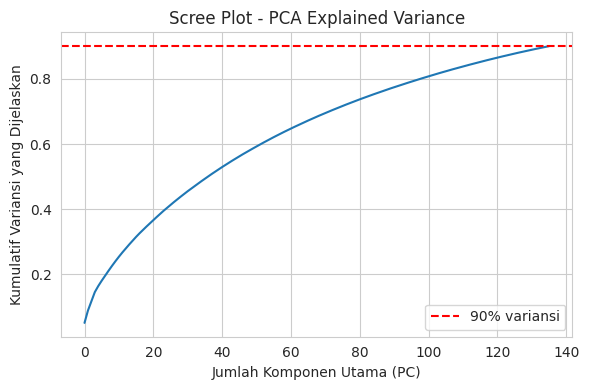

In [8]:
plt.figure(figsize=(6,4))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Jumlah Komponen Utama (PC)")
plt.ylabel("Kumulatif Variansi yang Dijelaskan")
plt.title("Scree Plot - PCA Explained Variance")
plt.axhline(0.9, color="red", linestyle="--", label="90% variansi")
plt.legend()
plt.tight_layout()
plt.show()


## 6. Klasifikasi dengan KNN

Tahapan:
1. Split data train-test (stratified, karena data imbalance)
2. Balancing data latih (oversampling kelas minoritas / fail) agar KNN tidak bias ke kelas mayoritas
3. Pencarian hyperparameter terbaik (`k` dan `weights`) dengan `GridSearchCV`
4. Training model KNN final

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y_raw, test_size=0.25, stratify=y_raw, random_state=RANDOM_STATE
)

# Balancing data latih dengan oversampling kelas minoritas (fail = 1)
train_df = pd.DataFrame(X_train)
train_df["label"] = y_train.values

majority = train_df[train_df.label == -1]
minority = train_df[train_df.label == 1]

if 0 < len(minority) < len(majority):
    minority_upsampled = resample(minority, replace=True, n_samples=len(majority), random_state=RANDOM_STATE)
    train_bal = pd.concat([majority, minority_upsampled])
else:
    train_bal = train_df

X_train_bal = train_bal.drop(columns="label").values
y_train_bal = train_bal["label"].values

print("Distribusi kelas data latih setelah balancing:")
print(pd.Series(y_train_bal).value_counts())


Distribusi kelas data latih setelah balancing:
-1    1097
 1    1097
Name: count, dtype: int64


In [10]:
param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 15],
    "weights": ["uniform", "distance"],
}

knn = KNeighborsClassifier()
grid_search = GridSearchCV(
    knn, param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="roc_auc",
    n_jobs=-1,
)
grid_search.fit(X_train_bal, y_train_bal)

print("Parameter terbaik:", grid_search.best_params_)
print("Skor ROC-AUC CV terbaik:", grid_search.best_score_)

best_knn = grid_search.best_estimator_


Parameter terbaik: {'n_neighbors': 15, 'weights': 'distance'}
Skor ROC-AUC CV terbaik: 0.9930868925699101


In [11]:
y_pred = best_knn.predict(X_test)
y_proba = best_knn.predict_proba(X_test)[:, 1]  # probabilitas kelas 'fail' (1)

print("Akurasi pada data uji:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=["Pass (-1)", "Fail (1)"]))


Akurasi pada data uji: 0.6683673469387755

              precision    recall  f1-score   support

   Pass (-1)       0.95      0.68      0.79       366
    Fail (1)       0.11      0.54      0.18        26

    accuracy                           0.67       392
   macro avg       0.53      0.61      0.48       392
weighted avg       0.90      0.67      0.75       392



## 7. Analisis Hasil Klasifikasi (TP-4, TP-5, TP-6)

Analisis dilakukan menggunakan:
- Confusion Matrix
- ROC Curve & AUC
- Histogram distribusi probabilitas prediksi
- Sebaran (scatter) data hasil klasifikasi pada ruang komponen utama

### 7.1 Confusion Matrix

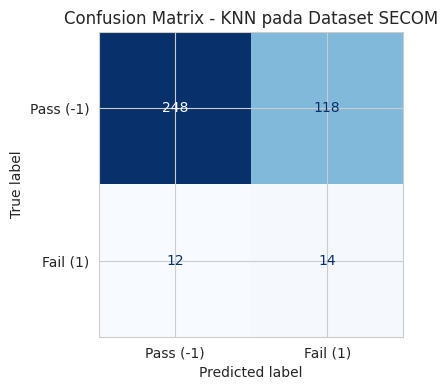

In [12]:
cm = confusion_matrix(y_test, y_pred, labels=[-1, 1])

fig, ax = plt.subplots(figsize=(5,4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Pass (-1)", "Fail (1)"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - KNN pada Dataset SECOM")
plt.tight_layout()
plt.show()


### 7.2 ROC Curve & AUC

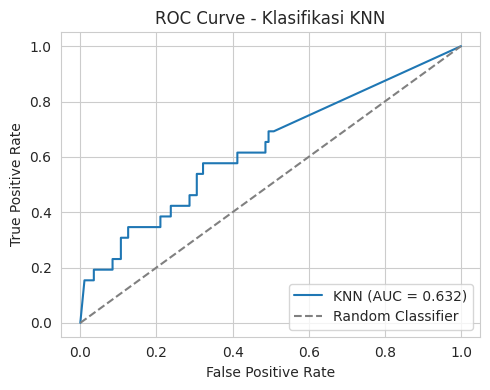

AUC: 0.6316729718369063


In [13]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba, pos_label=1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"KNN (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Klasifikasi KNN")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("AUC:", roc_auc)


### 7.3 Histogram Distribusi Probabilitas Prediksi

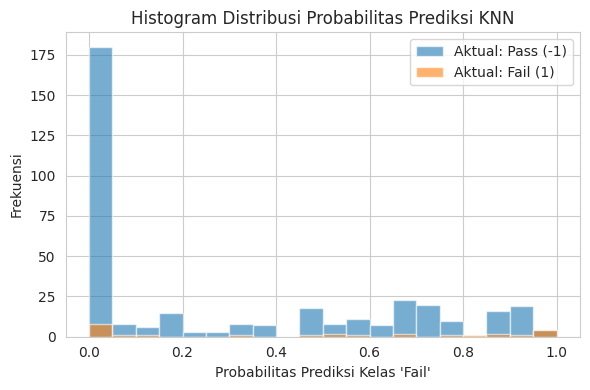

In [14]:
plt.figure(figsize=(6,4))
plt.hist(y_proba[y_test == -1], bins=20, alpha=0.6, label="Aktual: Pass (-1)")
plt.hist(y_proba[y_test == 1], bins=20, alpha=0.6, label="Aktual: Fail (1)")
plt.xlabel("Probabilitas Prediksi Kelas 'Fail'")
plt.ylabel("Frekuensi")
plt.title("Histogram Distribusi Probabilitas Prediksi KNN")
plt.legend()
plt.tight_layout()
plt.show()


### 7.4 Sebaran Data Hasil Klasifikasi (2 Komponen Utama PCA)

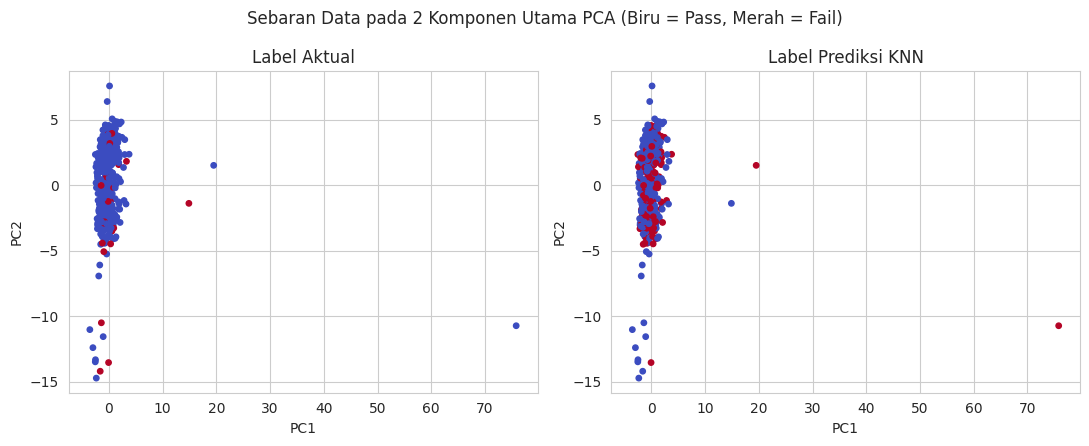

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sc1 = axes[0].scatter(X_test[:, 0], X_test[:, 1], c=(y_test == 1), cmap="coolwarm", s=15)
axes[0].set_title("Label Aktual")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

sc2 = axes[1].scatter(X_test[:, 0], X_test[:, 1], c=(y_pred == 1), cmap="coolwarm", s=15)
axes[1].set_title("Label Prediksi KNN")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.suptitle("Sebaran Data pada 2 Komponen Utama PCA (Biru = Pass, Merah = Fail)")
plt.tight_layout()
plt.show()


## 8. Ringkasan

Notebook ini telah menjalankan alur lengkap klasifikasi otomasi industri menggunakan dataset **SECOM** (semiconductor manufacturing, UCI) dengan metode **KNN**, meliputi:

- Preprocessing (missing value, fitur konstan, korelasi tinggi, scaling)
- Ekstraksi fitur dengan PCA
- Klasifikasi KNN dengan tuning hyperparameter
- Analisis hasil: Confusion Matrix, ROC-AUC, histogram probabilitas, dan sebaran data

**Langkah selanjutnya (di luar notebook ini):** menyusun hasil ini ke dalam format jurnal praktikum, lalu submit ke *Technology Sciences Insights Journal* dan mengunggahnya ke learning management system sesuai instruksi tugas.